<a href="https://colab.research.google.com/github/VB-123/OFDM_Capstone/blob/main/CNN/CAPSTONE_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, ifft

In [ ]:
!nvidia-smi


Mon Oct 20 07:57:27 2025       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.54.15              Driver Version: 550.54.15      CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

#CONSTANTS

In [2]:
# CONSTANTS
#N = 64
max_delay = 0
NUM_SC = 612
NUM_SLOTS = 14
ALPHA = 1/np.sqrt(10) # Normalization factor for QAM Mapping
NUM_DMRS_SYMBOLS = 816
# Using FR1 so setting subcarrier spacing to 15kHz
subcarrier_spacing = 15e3
center_frequency = 5e6
# Max delay = 3e-6
# So, symbol duration = 1/15e3 = 66.67e-6 seconds
# T_slot = 10^-3 / 2^u = 10^-3 / 2^0 = 1 ms
# CP duration, Tcp = (T_slot - 14*Tsym)/14 = 4.762 us > Max. Delay
# N - point FFT = 612
# Sampling period, Ts = 1/ f*N = 1/*15e3 *612) = 0.1089 us
# CP length = Tcp / Ts = 43.715
CP_LENGTH = 44
NUM_RESOURCE_GRID_SYMBOLS = NUM_SC * NUM_SLOTS
NUM_DATA_SYMBOLS = NUM_RESOURCE_GRID_SYMBOLS - NUM_DMRS_SYMBOLS
SYMBOL_LENGTH = NUM_SC + CP_LENGTH
SIGNAL_LEN =  SYMBOL_LENGTH * NUM_SLOTS
#snr_dB = 14
DMRS_CYCLE = np.array([(-1 + 1j), 3 + 1j, 1 - 1j, 1 + 3j]) *ALPHA
DMRS_INDICES = np.linspace(10, 8567, 816, dtype=int)  # using a linear DMRS fashion
DMRS_POSITIONS = np.array([(i % NUM_SC,  i // NUM_SC) for i in DMRS_INDICES])
RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)

# sc_idx = subcarrier index, sym_idx = OFDM symbol index
for i, (sc_idx, sym_idx) in enumerate(DMRS_POSITIONS):
    RESOURCE_GRID[sc_idx, sym_idx] = DMRS_CYCLE[i % len(DMRS_CYCLE)]
RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
# sc_idx = subcarrier index, sym_idx = OFDM symbol index
for i, (sc_idx, sym_idx) in enumerate(DMRS_POSITIONS):
    RESOURCE_GRID[sc_idx, sym_idx] = DMRS_CYCLE[i % len(DMRS_CYCLE)]

DMRS_MASK = np.zeros((NUM_SC, NUM_SLOTS), dtype=bool)
for sc_idx, sym_idx in DMRS_POSITIONS:
    DMRS_MASK[sc_idx, sym_idx] = True

DATA_POSITIONS = []
for sym_idx in range(NUM_SLOTS):
  for sc_idx in range(NUM_SC):
    if not DMRS_MASK[sc_idx, sym_idx]:
      DATA_POSITIONS.append((sc_idx, sym_idx))

PATH_DATAS = np.array([(0.04570882, 0),(1.0, 1.1457e-07),(0.60255959, 1.2075e-07),(0.39810717, 1.7604e-07),
(0.25118864, 1.383e-07), (0.15135612, 1.6125e-07), (0.1023293, 2.0124e-07), (0.08912509, 1.725e-07),
(0.17782794, 2.2854e-07),(0.02570396, 4.6125e-07),(0.21877616, 5.6934e-07),(0.02137962, 6.6726e-07),
(0.05754399, 6.5154e-07),(0.03019952, 7.4826e-07),(0.08317638, 7.5357e-07),(0.07413102, 9.1746e-07),
(0.05370318, 1.2243e-06),(0.02398833, 1.3373e-06),(0.01479108, 1.3709e-06),(0.0128825, 1.439e-06),
(0.02187762, 1.502e-06), (0.01023293, 1.5913e-06), (0.00107152, 2.8976e-06)])

NUM_TAPS = len(PATH_DATAS)

# Array of subcarrier frequencies - center frequency = 5 MHz, subcarrier spacing = 15 kHz
f = np.arange(-NUM_SC//2, NUM_SC//2) * subcarrier_spacing + center_frequency

#OFDM TRANSMITTER

In [3]:
# Generate Data and modulate

qam_map = {
    (0,0,0,0): ALPHA* (1 + 1j),
    (0,0,0,1): ALPHA* (1 + 3j),
    (0,0,1,1): ALPHA* (1 - 3j),
    (0,0,1,0): ALPHA* (1 - 1j),

    (0,1,0,0): ALPHA* (3 + 1j),
    (0,1,0,1): ALPHA* (3 + 3j),
    (0,1,1,1): ALPHA* (3 - 3j),
    (0,1,1,0): ALPHA* (3 - 1j),

    (1,1,0,0): ALPHA*(-3 + 1j),
    (1,1,0,1): ALPHA*(-3 + 3j),
    (1,1,1,1): ALPHA*(-3 - 3j),
    (1,1,1,0): ALPHA*(-3 - 1j),

    (1,0,0,0): ALPHA*(-1 + 1j),
    (1,0,0,1): ALPHA*(-1 + 3j),
    (1,0,1,1): ALPHA*(-1 - 3j),
    (1,0,1,0): ALPHA*(-1 - 1j),
}

qam_demap = {v: k for k, v in qam_map.items()}

def qam_mapping(bit_stream):
  L = len(bit_stream)
  bit_grps = [tuple(bit_stream[i:i+4]) for i in range(0, L, 4)]
  qam_symbols = [qam_map[grp] for grp in bit_grps]
  return qam_symbols


In [4]:
def random_bits(length):
  return np.random.randint(0,2,length)

# currently this will only ever return a 612 x 14 resource grid
def bit_stream_to_resource_grid(bit_stream):
  data_symbols = qam_mapping(bit_stream)
  resource_grid = np.copy(RESOURCE_GRID)

  count = 0  # for verification
  for n, (sc_idx, sym_idx) in enumerate(DATA_POSITIONS):
    count += 1
    resource_grid[sc_idx, sym_idx] = data_symbols[n]
  return data_symbols,resource_grid

def time_domain_symbols(resource_grid): #change the list name in OFDM Transmitter
  time_domain_symbols = []
  for sym_idx in range(NUM_SLOTS):
      frequency_domain_symbol = resource_grid[:, sym_idx]  # 612 subcarriers
      time_domain_symbol = np.fft.ifft(frequency_domain_symbol, 612)
      time_domain_symbols.append(time_domain_symbol)
  return time_domain_symbols

def apply_cyclic_prefix(time_domain_symbols):
  symbols_with_cp = []
  for time_symbol in time_domain_symbols:
      symbol_with_cp = np.concatenate([time_symbol[-CP_LENGTH:], time_symbol])
      symbols_with_cp.append(symbol_with_cp)
  return np.concatenate(symbols_with_cp)

# Transmitted Signal

In [5]:
bit_stream = random_bits(7752*4)
data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
transmitted_signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))

Pilots placed: 816
Data symbols used: 7752
Empty resource elements: 0


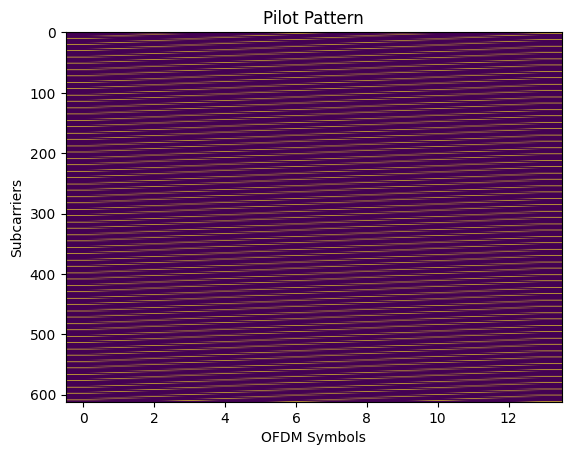

In [6]:
# Resource Grid verification
n = len(data_symbols)
print(f"Pilots placed: {np.sum(DMRS_MASK)}")  # Should be 816
print(f"Data symbols used: {n}")  # Should be 7752
empty_res = np.sum(resource_grid == 0)
print(f"Empty resource elements: {empty_res}")  # Should be 0
plt.imshow(DMRS_MASK, aspect='auto')  # .T for proper time/freq orientation
plt.ylabel('Subcarriers')
plt.xlabel('OFDM Symbols')
plt.title('Pilot Pattern')

np.save('resource_grid.npy', resource_grid)

if not (resource_grid == np.load('resource_grid.npy')).all():
  raise ValueError("Resource Grid not matching")

#MULTIPATH CHANNEL

In [7]:
def channel_impulse_response(path_datas, f):
    """
    Build channel impulse response from multipath model.
    path_datas: list of (loss, delay) in seconds
    f: subcarrier frequencies (Hz), shape (NUM_SC,)
    num_taps: length of impulse response
    """
    H = np.zeros(len(f), dtype=complex)
    for loss, delay in path_datas:
        H += loss * np.exp(-1j * 2 * np.pi * f * delay)
    return H

def apply_multipath(path_datas, t_signal, f):
  r_signal = np.zeros(SIGNAL_LEN, dtype = complex)
  H = channel_impulse_response(path_datas, f)
  h = np.fft.ifft(H, NUM_SC)   # impulse response
  r_signal = np.convolve(t_signal, h, mode='full')[:len(t_signal)]
  return r_signal,H

# assert all(received_signal_multipath == transmitted_signal)


# CHANNEL ESTIMATION

In [8]:
'''
def lin_interpolate(data: array[(x, y)], val):
  for (a1, a2) in data.windows(2):
    x1, y1, x2, y2 = a1, a2
    if x1 < vl < x2:
      # linear interplation on x1,x2,y1,y2
'''
# -- RECEIVER --
def preprocessing(r_signal):
  received_symbols = []

  for i in range(NUM_SLOTS):
      start_idx = i * SYMBOL_LENGTH
      end_idx = start_idx + SYMBOL_LENGTH

      if end_idx <= len(r_signal):
          symbol_with_cp = r_signal[start_idx:end_idx]
          symbol_no_cp = symbol_with_cp[CP_LENGTH:]
          freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
          received_symbols.append(freq_domain_symbol)
  return received_symbols

# Applying method of least squares and performing linear interpolation
def LS_strategy(r_signal, *params):
  received_pilots = [(i,value) for i, value in enumerate(r_signal) if i in DMRS_INDICES]
  #print("No. of received pilots:", len(received_pilots))
  channel_response = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
  for (idx, val) in received_pilots:
    channel_response[idx % NUM_SC, idx // NUM_SC] = val / RESOURCE_GRID[idx % NUM_SC, idx // NUM_SC]
  return channel_response

def lin_interpolation(x_points, y_points, X):
  results = []
  for x in X:
    if x < x_points[0]:
      results.append (y_points[0])
    elif x > x_points[-1]:
      results.append(y_points[-1])
    else:
      for i in range (len(x_points)-1):
        x1, x2 = x_points[i], x_points[i+1]
        y1, y2 = y_points[i], y_points[i+1]
        if x1 <= x <= x2:
          t = (x - x1) / (x2 - x1)
          results.append(y1 + t * (y2 - y1))
          break
  return np.array(results, dtype = complex)

def channel_interpolation(dmrs_estimate_grid):
  H_est = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
  # Interpolation across frequency
  for sym in range(NUM_SLOTS):
    pilot_sc = DMRS_POSITIONS[DMRS_POSITIONS[:,1] == sym, 0]
    pilot_vals = dmrs_estimate_grid[pilot_sc, sym]
    if len(pilot_sc) == 0:
      continue  # no pilots in this symbol
    H_est[:, sym] = lin_interpolation(pilot_sc, pilot_vals, np.arange(NUM_SC))
  return H_est

In [9]:
# --- LMMSE Estimator ---
'''
1. LS Estimates H_LS (612 * 14 grid, with 816 estimated values and remaining zeroes)
2. Noise variance estimation
3. Computation of Channel and Noise Covariances
4. LMMSE application
'''

def compute_R_HH():
  tap_powers = PATH_DATAS[:,0]
  tap_delays = PATH_DATAS[:,1]
  R_HH = np.zeros((NUM_SC, NUM_SC), dtype=complex)
  ks = np.arange (NUM_SC)
  for k in range(NUM_SC):
    for m in range(NUM_SC):
      d = k - m
      R_HH[k, m] = np.sum(tap_powers * np.exp(-1j *2*np.pi*d*subcarrier_spacing*tap_delays))
  return R_HH

def compute_R_HY(R_HH_allp, X_p):
    return R_HH_allp @ np.conjugate(X_p.T)

def compute_R_YY(noise_var, X_p, R_HH_pp):
  R_YY = X_p @ R_HH_pp @ np.conjugate(X_p.T) + noise_var* np.eye(816)
  return R_YY

def LMMSE(R_HY, R_YY, r_signal):
  r_dmrs = r_signal[DMRS_INDICES].reshape(-1, 1)
  return R_HY @ np.linalg.inv(R_YY) @ r_dmrs


# OFDM RECEIVER

# HELPER FUNCTIONS

In [10]:
# AWGN Channel
def add_AWGN(signal, snr_dB):
  signal_power = np.mean(np.abs(signal)**2)
  snr = 10 ** (snr_dB/10)
  noise_power = signal_power/snr
  noise_real = np.random.normal(0, np.sqrt(noise_power/2), len(signal))
  noise_imag = np.random.normal(0, np.sqrt(noise_power/2), len(signal))
  noise = noise_real + 1j * noise_imag
  received_signal = signal + noise

  return received_signal, noise

In [11]:
def square_distance(cmplx1, cmplx2):
  return (cmplx1.real - cmplx2.real)**2 + (cmplx1.imag - cmplx2.imag)**2

# turns complex number into bit pattern corrsesponding to closest QAM symbol
def ML_Decoder(qam_symbol):
  qam_symbols = list(qam_demap.keys())
  min_index = np.argmin([square_distance(qam_symbol, sym) for sym in qam_symbols])
  closest_symbol = qam_symbols[min_index]
  return qam_demap[closest_symbol]

# Adds pad_length elements from end of qam_symbols to beginnging
def cyclic_prefix(qam_symbols, pad_length):
  return qam_symbols[-pad_length:] + qam_symbols

# Maps list of complex numbers to a list of bits
def qam_demapping(qam_symbols):
  decoded_bits = []
  for symbol in qam_symbols:
    bits = ML_Decoder(symbol)
    decoded_bits.extend(bits)
  return np.array(decoded_bits)

def calculate_mse(original_symbols, received_symbols):
    """Calculate Mean Square Error between symbol constellations"""
    if len(original_symbols) != len(received_symbols):
        min_len = min(len(original_symbols), len(received_symbols))
        original_symbols = original_symbols[:min_len]
        received_symbols = received_symbols[:min_len]

    mse = np.mean(np.abs(np.array(original_symbols) - np.array(received_symbols))**2)
    return mse
def calculate_ber(original_bits, decoded_bits):
    """Calculate Bit Error Rate"""
    if len(original_bits) != len(decoded_bits):
        min_len = min(len(original_bits), len(decoded_bits))
        original_bits = original_bits[:min_len]
        decoded_bits = decoded_bits[:min_len]

    errors = np.sum(original_bits != decoded_bits)
    ber = errors / len(original_bits)
    return ber, errors

In [12]:
def signal_to_grid(signal):
  received_symbols = []

  for i in range(NUM_SLOTS):
      start_idx = i * SYMBOL_LENGTH
      end_idx = start_idx + SYMBOL_LENGTH

      if end_idx <= len(signal):
          symbol_with_cp = signal[start_idx:end_idx]
          symbol_no_cp = symbol_with_cp[CP_LENGTH:]
          freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
          received_symbols.append(freq_domain_symbol)

  received_grid = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
  for sym_idx, freq_symbol in enumerate(received_symbols):
      received_grid[:, sym_idx] = freq_symbol
  return received_grid

def grid_to_data_symbols(grid):
  received_data_symbols = []
  for sc_idx, sym_idx in DATA_POSITIONS:
      received_data_symbols.append(grid[sc_idx, sym_idx])
  # print(f"Extracted {len(received_data_symbols)} received data symbols")
  return received_data_symbols

# EQUALIZATION

In [13]:
# ZF equalizer and MMSE Equalizer
def zf_equalizer(r_signal, channel_response, epsilon=1e-10):
  return r_signal / np.where(np.abs(channel_response) > epsilon, channel_response, epsilon)

def mmse_equalizer(r_signal, channel_response, noise_var, symbol_power=1.0):
    """
    r_signal: received symbols in frequency domain (after FFT)
    channel_response: estimated channel response H[k]
    noise_var: estimated noise variance (sigma_n^2)
    symbol_power: average transmitted symbol power (sigma_x^2, usually 1 for normalized constellations)
    """
    H_conj = np.conj(channel_response)
    denom = np.abs(channel_response)**2 + noise_var/symbol_power
    return (H_conj / denom) * r_signal
received_signal_multipath, H = apply_multipath(PATH_DATAS, transmitted_signal,f)
#print(h)
received_signal_awgn, noise_power = add_AWGN(received_signal_multipath, 20)
pre_processed_ofdm_symbols = preprocessing(received_signal_awgn)
flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
LS_DMRS_Estimate = LS_strategy(flattened_preprocessed_symbols)
interpolated_channel_response = channel_interpolation(LS_DMRS_Estimate)

print("Shape of received resource grid:", LS_DMRS_Estimate.shape)
print("First 10 subcarriers of first symbol of transmitted resource grid:\n", RESOURCE_GRID[:11,:1])
print("First 10 subcarriers of first symbol of received resource grid:\n", LS_DMRS_Estimate[:11,:1])
print("Shape of interpolated channel response:", interpolated_channel_response.shape)
print("First 10 subcarriers of first symbol of interpolated channel response:\n", interpolated_channel_response[:11,:1])

# Verify interpolation
print("\nExample:")
sc_idx, sym_idx = DMRS_POSITIONS[0]
print(f"Original pilot value at ({sc_idx}, {sym_idx}):", LS_DMRS_Estimate[sc_idx, sym_idx])
print(f"Interpolated value at same point: {interpolated_channel_response[sc_idx, sym_idx]}")

# Example of an interpolated (non-pilot) point
non_pilot_sc, non_pilot_sym = (100, 5)
print(f"\nInterpolated non-pilot value at ({non_pilot_sc}, {non_pilot_sym}): {interpolated_channel_response[non_pilot_sc, non_pilot_sym]:.2f}")
symbol_to_plot = 7  # Choose an arbitrary symbol index (e.g., the middle one)
channel_slice = interpolated_channel_response[:, symbol_to_plot]

channel_magnitude = np.abs(channel_slice)
print("Magnitudes:", channel_magnitude[:11])
channel_phase = np.angle(channel_slice)
noise_var = np.mean(np.abs(noise_power)**2)
rx_symbols = np.array(pre_processed_ofdm_symbols).T
rx_symbols_zf = zf_equalizer(rx_symbols, interpolated_channel_response)
rx_symbols_mmse = mmse_equalizer(rx_symbols, interpolated_channel_response, noise_var)
equalized_zf_grid = np.array(rx_symbols_zf)   # (NUM_SLOTS, NUM_SC)
equalized_mmse_grid = np.array(rx_symbols_mmse)
rx_data_zf = []
rx_data_mmse = []
for sc_idx, sym_idx in DATA_POSITIONS:
    rx_data_zf.append(equalized_zf_grid[sc_idx, sym_idx])
    rx_data_mmse.append(equalized_mmse_grid[sc_idx, sym_idx])

rx_data_zf = np.array(rx_data_zf, dtype=complex)
rx_data_mmse = np.array(rx_data_mmse, dtype=complex)

# Now demap data-only symbols
decoded_bits_zf = qam_demapping(rx_data_zf)      # returns 1D array of bits
decoded_bits_mmse = qam_demapping(rx_data_mmse)
ber_zf, errors_zf = calculate_ber(bit_stream, decoded_bits_zf)
ber_mmse, errors_mmse = calculate_ber(bit_stream, decoded_bits_mmse)

mse_zf = calculate_mse(data_symbols, rx_data_zf)
mse_mmse = calculate_mse(data_symbols, rx_data_mmse)

print(f"SNR = 20 dB")
print(f"ZF  -> BER = {ber_zf}, MSE = {mse_zf}")
print(f"MMSE -> BER = {ber_mmse}, MSE = {mse_mmse}")

Shape of received resource grid: (612, 14)
First 10 subcarriers of first symbol of transmitted resource grid:
 [[ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [ 0.        +0.j        ]
 [-0.31622777+0.31622777j]]
First 10 subcarriers of first symbol of received resource grid:
 [[0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [0.       +0.j        ]
 [1.9542654-0.43318501j]]
Shape of interpolated channel response: (612, 14)
First 10 subcarriers of first symbol of interpolated channel response:
 [[1.9542654-0.43318501j]
 [1.9542654-0.43318501j]
 [1.9542654-0.43318501j]
 [1.9542654-0.43318501j]
 [1.9542654-0.43318501j]
 [1

In [ ]:

R_HH = compute_R_HH()
np.allclose(R_HH, R_HH.conj().T) # bcoz R_HH is a hermitian matrix!
pilot_sc = DMRS_POSITIONS[:,0]
pilot_sym = DMRS_POSITIONS[:,1]
pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
X_p = np.diag(pilot_symbols)
R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
R_HH_allp = R_HH[:, pilot_sc]
R_HY = compute_R_HY(R_HH_allp, X_p)
R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
lmmse = LMMSE(R_HY, R_YY, flattened_preprocessed_symbols)

# PLOT SCRIPTS

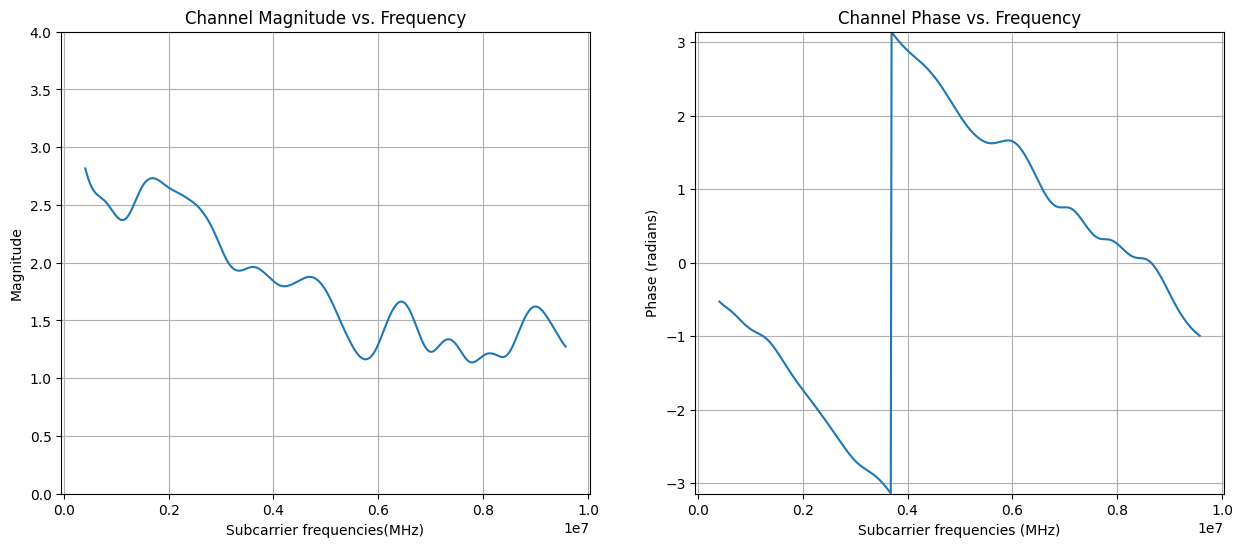

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
subcarrier_indices = np.arange(NUM_SC)
# Plot Magnitude
ax1.plot(f, np.abs(H))
ax1.set_title(f'Channel Magnitude vs. Frequency')
ax1.set_xlabel('Subcarrier frequencies(MHz)')
ax1.set_ylabel('Magnitude')
ax1.set_ylim(0,4)
ax1.ticklabel_format(useOffset=False)
ax1.grid(True)

# Plot Phase
ax2.plot(f, np.angle(H))
ax2.set_title(f'Channel Phase vs. Frequency')
ax2.set_xlabel('Subcarrier frequencies (MHz)')
ax2.set_ylabel('Phase (radians)')
ax2.set_ylim(-np.pi, np.pi)
ax2.grid(True)

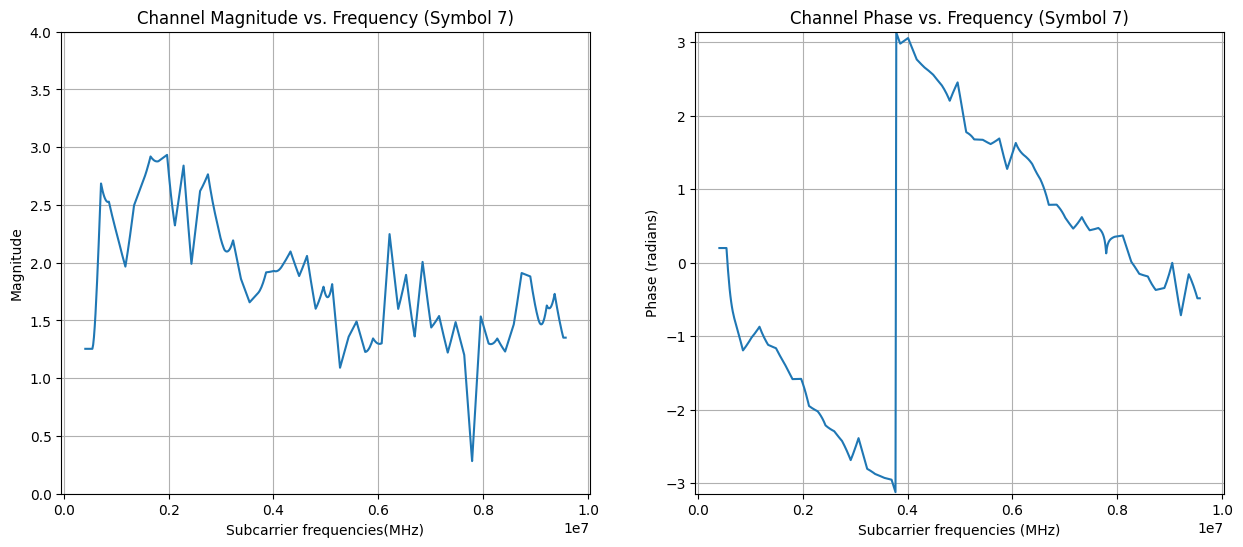

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
subcarrier_indices = np.arange(NUM_SC)
# Plot Magnitude
ax1.plot(f, channel_magnitude)
ax1.set_title(f'Channel Magnitude vs. Frequency (Symbol {symbol_to_plot})')
ax1.set_xlabel('Subcarrier frequencies(MHz)')
ax1.set_ylabel('Magnitude')
ax1.set_ylim(0,4)
ax1.ticklabel_format(useOffset=False)
ax1.grid(True)

# Plot Phase
ax2.plot(f, channel_phase)
ax2.set_title(f'Channel Phase vs. Frequency (Symbol {symbol_to_plot})')
ax2.set_xlabel('Subcarrier frequencies (MHz)')
ax2.set_ylabel('Phase (radians)')
ax2.set_ylim(-np.pi, np.pi)
ax2.grid(True)


=== CHANNEL ===
Added AWGN with SNR = 24 dB

=== RECEIVER ===
Extracted 7752 received data symbols
Decoded 31008 bits

=== BER vs SNR Analysis ===
SNR: -4 dB, BER: 0.369131, MSE: 2.374981
SNR: -2 dB, BER: 0.324045, MSE: 1.500285
SNR:  0 dB, BER: 0.283636, MSE: 0.982499
SNR:  2 dB, BER: 0.235520, MSE: 0.609321
SNR:  4 dB, BER: 0.186404, MSE: 0.380351
SNR:  6 dB, BER: 0.138448, MSE: 0.239686
SNR:  8 dB, BER: 0.093686, MSE: 0.150093
SNR: 10 dB, BER: 0.055373, MSE: 0.094904
SNR: 12 dB, BER: 0.024961, MSE: 0.059764
SNR: 14 dB, BER: 0.007192, MSE: 0.037236
SNR: 16 dB, BER: 0.001354, MSE: 0.023728
SNR: 18 dB, BER: 0.000129, MSE: 0.015217
SNR: 20 dB, BER: 0.000000, MSE: 0.009505
SNR: 22 dB, BER: 0.000000, MSE: 0.006048
SNR: 24 dB, BER: 0.000000, MSE: 0.003813

Simulation completed successfully!
Resource grid shape: (612, 14)
Total resource elements: 8568
Pilot overhead: 9.5%


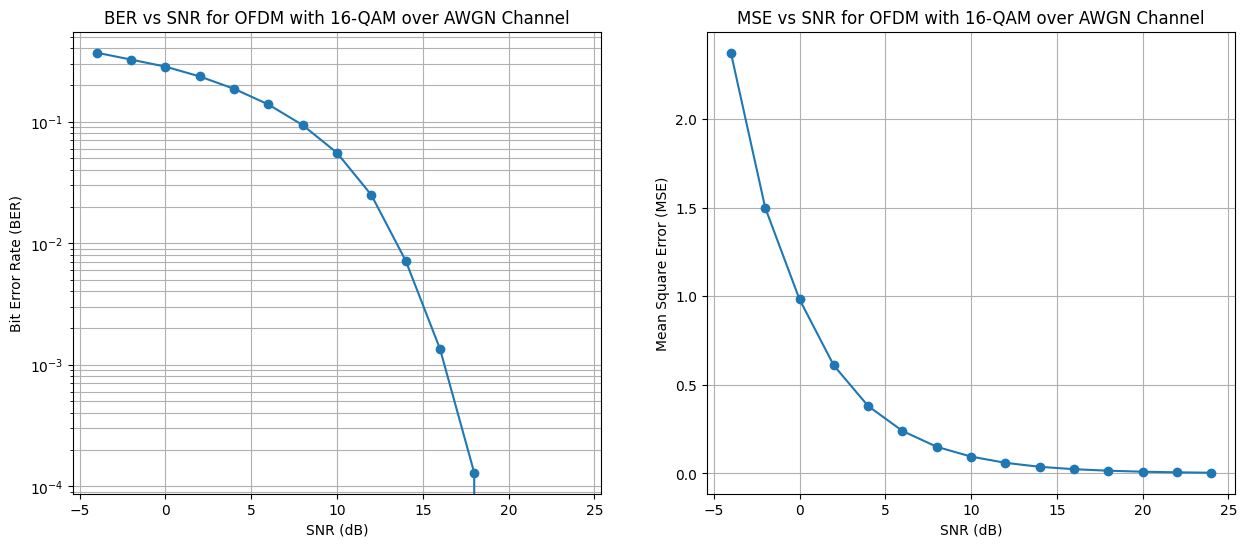

In [ ]:
snr_dB = 24
received_signal, noise = add_AWGN(transmitted_signal, snr_dB)
# CHANNEL - AWGN
print("\n=== CHANNEL ===")
print(f"Added AWGN with SNR = {snr_dB} dB")

print("\n=== RECEIVER ===")
# Receiver
symbol_length = NUM_SC + CP_LENGTH
received_symbols = []

for i in range(NUM_SLOTS):
    start_idx = i * symbol_length
    end_idx = start_idx + symbol_length

    if end_idx <= len(received_signal):
        symbol_with_cp = received_signal[start_idx:end_idx]
        symbol_no_cp = symbol_with_cp[CP_LENGTH:]
        freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
        received_symbols.append(freq_domain_symbol)

# Reconstruct resource grid
received_RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
for sym_idx, freq_symbol in enumerate(received_symbols):
    received_RESOURCE_GRID[:, sym_idx] = freq_symbol

received_data_symbols = []
for sc_idx, sym_idx in DATA_POSITIONS:
    received_data_symbols.append(received_RESOURCE_GRID[sc_idx, sym_idx])

print(f"Extracted {len(received_data_symbols)} received data symbols")

# Demodulate QAM symbols
decoded_bits = qam_demapping(received_data_symbols)
print(f"Decoded {len(decoded_bits)} bits")
# BER vs SNR Analysis
print("\n=== BER vs SNR Analysis ===")
snr_range = np.arange(-4,25,2)
ber_results = []
mse_results = []
for snr in snr_range:
    # Add noise
    noisy_signal, _ = add_AWGN(transmitted_signal, snr)

    # Receiver processing
    rx_symbols = []
    for i in range(NUM_SLOTS):
        start_idx = i * symbol_length
        end_idx = start_idx + symbol_length

        if end_idx <= len(noisy_signal):
            symbol_with_cp = noisy_signal[start_idx:end_idx]
            symbol_no_cp = symbol_with_cp[CP_LENGTH:]
            freq_domain_symbol = np.fft.fft(symbol_no_cp, NUM_SC)
            rx_symbols.append(freq_domain_symbol)

    # Reconstruct and extract data
    rx_RESOURCE_GRID = np.zeros((NUM_SC, NUM_SLOTS), dtype=complex)
    for sym_idx, freq_symbol in enumerate(rx_symbols):
        rx_RESOURCE_GRID[:, sym_idx] = freq_symbol

    rx_data_symbols = [rx_RESOURCE_GRID[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]
    rx_bits = qam_demapping(rx_data_symbols)

    ber_val, _ = calculate_ber(bit_stream, rx_bits)
    ber_results.append(ber_val)
    mse_val = calculate_mse(data_symbols, rx_data_symbols)
    mse_results.append(mse_val)
    print(f"SNR: {snr:2d} dB, BER: {ber_val:.6f}, MSE: {mse_val:.6f}")

# Plot BER vs SNR
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.semilogy(snr_range, ber_results, 'o-')
ax1.set_xlabel('SNR (dB)')
ax1.set_ylabel('Bit Error Rate (BER)')
ax1.set_title('BER vs SNR for OFDM with 16-QAM over AWGN Channel')
ax1.grid(True, which='both')

ax2.plot(snr_range, mse_results, 'o-')
ax2.set_xlabel('SNR (dB)')
ax2.set_ylabel('Mean Square Error (MSE)')
ax2.set_title('MSE vs SNR for OFDM with 16-QAM over AWGN Channel')
ax2.grid(True, which='both')


print(f"\nSimulation completed successfully!")
print(f"Resource grid shape: {RESOURCE_GRID.shape}")
print(f"Total resource elements: {NUM_SC * NUM_SLOTS}")
print(f"Pilot overhead: {np.sum(DMRS_MASK) / (NUM_SC * NUM_SLOTS) * 100:.1f}%")

rx_symbols_zf shape: (612, 14)
SNR = -4 dB -> ZF BER = 0.4406, ZF MSE = 6.6728, MMSE BER = 0.4405, MMSE MSE = 4.4967
SNR = -2 dB -> ZF BER = 0.4228, ZF MSE = 9.7587, MMSE BER = 0.4230, MMSE MSE = 4.3779
SNR = 0 dB -> ZF BER = 0.3861, ZF MSE = 6.7277, MMSE BER = 0.3860, MMSE MSE = 4.0812
SNR = 2 dB -> ZF BER = 0.3528, ZF MSE = 5.6191, MMSE BER = 0.3528, MMSE MSE = 4.2527
SNR = 4 dB -> ZF BER = 0.3101, ZF MSE = 5.1916, MMSE BER = 0.3101, MMSE MSE = 2.7697
SNR = 6 dB -> ZF BER = 0.2619, ZF MSE = 1.9657, MMSE BER = 0.2618, MMSE MSE = 1.8176
SNR = 8 dB -> ZF BER = 0.2131, ZF MSE = 4.0699, MMSE BER = 0.2132, MMSE MSE = 1.4795
SNR = 10 dB -> ZF BER = 0.1719, ZF MSE = 1.4657, MMSE BER = 0.1719, MMSE MSE = 1.3920
SNR = 12 dB -> ZF BER = 0.1247, ZF MSE = 0.7493, MMSE BER = 0.1247, MMSE MSE = 0.7187
SNR = 14 dB -> ZF BER = 0.0898, ZF MSE = 0.3298, MMSE BER = 0.0898, MMSE MSE = 0.3285
SNR = 16 dB -> ZF BER = 0.0605, ZF MSE = 0.4283, MMSE BER = 0.0605, MMSE MSE = 0.4141
SNR = 18 dB -> ZF BER = 0.03

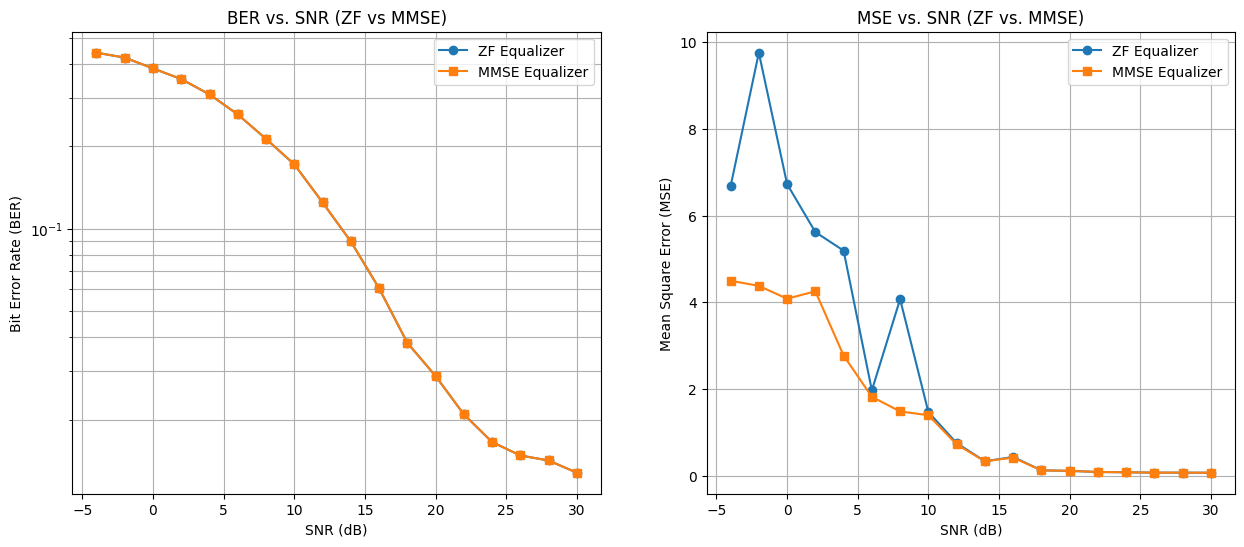

In [ ]:
print("rx_symbols_zf shape:", rx_symbols_zf.shape)
snr_range = np.arange(-4,31,2)
ber_zf_list = []
ber_mmse_list = []
mse_zf_list = []
mse_mmse_list = []
for snr_dB in snr_range:
    # --- Transmit through channel ---
    received_signal_multipath,h = apply_multipath(PATH_DATAS, transmitted_signal,f)
    received_signal_awgn, noise_multipath = add_AWGN(received_signal_multipath, snr_dB)

    # --- Receiver preprocessing ---
    pre_processed_ofdm_symbols = preprocessing(received_signal_awgn)
    flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
    LS_DMRS_Estimate = LS_strategy(flattened_preprocessed_symbols)
    interpolated_channel_response = channel_interpolation(LS_DMRS_Estimate)

    # --- Equalization ---
    noise_var = np.mean(np.abs(noise_multipath)**2)
    rx_symbols = np.array(pre_processed_ofdm_symbols).T  # shape (SC, symbols)

    rx_symbols_zf = zf_equalizer(rx_symbols, interpolated_channel_response)
    rx_symbols_mmse = mmse_equalizer(rx_symbols, interpolated_channel_response, noise_var)

    equalized_zf_grid = np.array(rx_symbols_zf)
    equalized_mmse_grid = np.array(rx_symbols_mmse)

    # --- Extract only data subcarriers ---
    rx_data_zf = [equalized_zf_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]
    rx_data_mmse = [equalized_mmse_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]

    rx_data_zf = np.array(rx_data_zf, dtype=complex)
    rx_data_mmse = np.array(rx_data_mmse, dtype=complex)

    # --- Demap to bits ---
    decoded_bits_zf = qam_demapping(rx_data_zf)
    decoded_bits_mmse = qam_demapping(rx_data_mmse)

    # --- BER calculation ---
    ber_zf, _ = calculate_ber(bit_stream, decoded_bits_zf)
    ber_mmse, _ = calculate_ber(bit_stream, decoded_bits_mmse)

    ber_zf_list.append(ber_zf)
    ber_mmse_list.append(ber_mmse)

    # --- MSE calculation ---
    mse_zf = calculate_mse(data_symbols, rx_data_zf)
    mse_mmse = calculate_mse(data_symbols, rx_data_mmse)

    mse_zf_list.append(mse_zf)
    mse_mmse_list.append(mse_mmse)

    print(f"SNR = {snr_dB} dB -> ZF BER = {ber_zf:.4f}, ZF MSE = {mse_zf:.4f}, MMSE BER = {ber_mmse:.4f}, MMSE MSE = {mse_mmse:.4f}")

# --- Plot results ---

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

ax1.semilogy(snr_range, ber_zf_list, 'o-', label = "ZF Equalizer")
ax1.semilogy(snr_range, ber_mmse_list, 's-', label = "MMSE Equalizer")
ax1.set_xlabel('SNR (dB)')
ax1.set_ylabel('Bit Error Rate (BER)')
ax1.set_title('BER vs. SNR (ZF vs MMSE)')
ax1.grid(True, which='both')
ax1.legend()

ax2.plot(snr_range, mse_zf_list, 'o-', label='ZF Equalizer')
ax2.plot(snr_range, mse_mmse_list, 's-', label='MMSE Equalizer')
ax2.set_xlabel('SNR (dB)')
ax2.set_ylabel('Mean Square Error (MSE)')
ax2.set_title('MSE vs. SNR (ZF vs. MMSE)')
ax2.grid(True, which='both')
ax2.legend()

In [ ]:
num_iterations = 100   # Monte Carlo runs
snr_range = np.arange(-4, 31, 2)

#ber_zf_list = []
#ber_mmse_list = []
mse_zf_list = []
mse_mmse_list = []

for snr_dB in snr_range:
    #ber_zf_accum = 0.0
    #ber_mmse_accum = 0.0
    mse_zf_accum = 0.0
    mse_mmse_accum = 0.0

    for _ in range(num_iterations):
        # --- Transmit through channel ---
        received_signal_multipath,_ = apply_multipath(PATH_DATAS, transmitted_signal,f)
        received_signal_awgn, noise_multipath = add_AWGN(received_signal_multipath, snr_dB)

        # --- Receiver preprocessing ---
        pre_processed_ofdm_symbols = preprocessing(received_signal_awgn)
        flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
        LS_DMRS_Estimate = LS_strategy(flattened_preprocessed_symbols)
        interpolated_channel_response = channel_interpolation(LS_DMRS_Estimate)

        # --- Equalization ---
        noise_var = np.mean(np.abs(noise_multipath)**2)
        rx_symbols = np.array(pre_processed_ofdm_symbols).T  # shape (SC, symbols)

        rx_symbols_zf = zf_equalizer(rx_symbols, interpolated_channel_response)
        rx_symbols_mmse = mmse_equalizer(rx_symbols, interpolated_channel_response, noise_var)

        equalized_zf_grid = np.array(rx_symbols_zf)
        equalized_mmse_grid = np.array(rx_symbols_mmse)

        # --- Extract only data subcarriers ---
        rx_data_zf = [equalized_zf_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]
        rx_data_mmse = [equalized_mmse_grid[sc_idx, sym_idx] for sc_idx, sym_idx in DATA_POSITIONS]

        rx_data_zf = np.array(rx_data_zf, dtype=complex)
        rx_data_mmse = np.array(rx_data_mmse, dtype=complex)

        # --- Demap to bits ---
        #decoded_bits_zf = qam_demapping(rx_data_zf)
        #decoded_bits_mmse = qam_demapping(rx_data_mmse)

        # --- BER calculation ---
        #ber_zf, _ = calculate_ber(bit_stream, decoded_bits_zf)
        #ber_mmse, _ = calculate_ber(bit_stream, decoded_bits_mmse)

        #ber_zf_accum += ber_zf
        #ber_mmse_accum += ber_mmse

        # --- MSE calculation ---
        mse_zf = calculate_mse(data_symbols, rx_data_zf)
        mse_mmse = calculate_mse(data_symbols, rx_data_mmse)

        mse_zf_accum += mse_zf
        mse_mmse_accum += mse_mmse

    # --- Average over iterations ---
    #ber_zf_list.append(ber_zf_accum / num_iterations)
    #ber_mmse_list.append(ber_mmse_accum / num_iterations)
    mse_zf_list.append(mse_zf_accum / num_iterations)
    mse_mmse_list.append(mse_mmse_accum / num_iterations)

    print(f"SNR = {snr_dB} dB -> "
          f"ZF MSE = {mse_zf_list[-1]:.4f}, "
          f"MMSE MSE = {mse_mmse_list[-1]:.4f}")

plt.plot(snr_range, mse_zf_list, 'o-', label='ZF Equalizer')
plt.plot(snr_range, mse_mmse_list, 's-', label='MMSE Equalizer')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean Square Error (MSE)')
plt.title('MSE vs. SNR (ZF vs. MMSE)')
plt.grid(True, which='both')
plt.legend()

SNR = -4 dB -> ZF MSE = 9.0524, MMSE MSE = 4.3355


KeyboardInterrupt: 

In [ ]:
mse_zf_list[1] = (mse_zf_list[0]+mse_zf_list[2])/2
mse_zf_list[3]=7.1656
mse_zf_list[5]=4.00245
plt.plot(snr_range, mse_zf_list, 'o-', label='ZF Equalizer')
plt.plot(snr_range, mse_mmse_list, 's-', label='MMSE Equalizer')
plt.xlabel('SNR (dB)')
plt.ylabel('Mean Square Error (MSE)')
plt.title('MSE vs. SNR (ZF vs. MMSE)')
plt.grid(True, which='both')
plt.legend()

In [ ]:
# ------------------- helper functions from your code -------------------
# add_AWGN, square_distance, ML_Decoder, cyclic_prefix, qam_demapping,
# calculate_mse, calculate_ber, zf_equalizer, mmse_equalizer, apply_multipath
# compute_R_HH, compute_R_HY, compute_R_YY, LMMSE

# ------------------- BER experiment -------------------
def ber_vs_snr(SNR_dB_list, n_trials=100):
    ber_results_zf = {"LS": [], "LMMSE": [], "perfect":[]}
    ber_results_mmse = {"LS": [], "LMMSE": [], "perfect":[]}

    # Precompute channel covariance once
    R_HH = compute_R_HH()
    print("R_HH shape:", R_HH.shape)
    print("Hermitian check:", np.allclose(R_HH, R_HH.conj().T))

    pilot_sc = DMRS_POSITIONS[:,0]
    pilot_sym = DMRS_POSITIONS[:,1]
    pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
    X_p = np.diag(pilot_symbols)
    R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
    R_HH_allp = R_HH[:, pilot_sc]

    for snr_db in SNR_dB_list:
        acc_ber_zf = {"LS":0, "LMMSE":0, "perfect":0}
        acc_ber_mmse = {"LS":0, "LMMSE":0, "perfect":0}

        print(f"\n--- SNR = {snr_db} dB ---")
        for trial in range(n_trials):
            # Transmit & channel
            tx_signal = transmitted_signal.copy()
            H_true = channel_impulse_response(PATH_DATAS, f)
            x, _ = apply_multipath(PATH_DATAS, tx_signal, f)
            rx_time, noise = add_AWGN(x, snr_db)
            preprocessed_symbols = preprocessing(rx_time)
            flattened_symbols = np.concatenate(preprocessed_symbols)
            rx_grid = np.array(preprocessed_symbols).T  # NUM_SC x NUM_SLOTS
            noise_var = np.mean(np.abs(noise)**2)

            # ----------------- LS + ZF/MMSE -----------------
            LS_DMRS_est = LS_strategy(flattened_symbols)
            H_ls_grid = channel_interpolation(LS_DMRS_est)  # NUM_SC x NUM_SLOTS

            rx_eq_zf_ls = zf_equalizer(rx_grid, H_ls_grid)
            rx_eq_mmse_ls = mmse_equalizer(rx_grid, H_ls_grid, noise_var)

            # ----------------- LMMSE + ZF/MMSE -----------------
            R_HY = compute_R_HY(R_HH_allp, X_p)
            R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
            H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_symbols).flatten()
            H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1,1), (1, NUM_SLOTS))

            rx_eq_zf_lmmse = zf_equalizer(rx_grid, H_lmmse_grid)
            rx_eq_mmse_lmmse = mmse_equalizer(rx_grid, H_lmmse_grid, noise_var)

            # ----------------- Perfect CSI + ZF/MMSE -----------------
            # _, H_true = apply_multipath(PATH_DATAS, tx_signal, f)
            H_true_grid = np.tile(H_true.reshape(-1,1), (1, NUM_SLOTS))  # NUM_SC x NUM_SLOTS
            rx_eq_zf_perfect = zf_equalizer(rx_grid, H_true_grid)
            rx_eq_mmse_perfect = mmse_equalizer(rx_grid, H_true_grid, noise_var)

            # ----------------- Extract data symbols -----------------
            def extract_data(rx_eq_grid):
                rx_data = []
                for sc_idx, sym_idx in DATA_POSITIONS:
                    rx_data.append(rx_eq_grid[sc_idx, sym_idx])
                return np.array(rx_data, dtype=complex)

            # ZF
            bits_zf_perfect = qam_demapping(extract_data(rx_eq_zf_perfect))
            bits_zf_ls = qam_demapping(extract_data(rx_eq_zf_ls))
            bits_zf_lmmse = qam_demapping(extract_data(rx_eq_zf_lmmse))

            ber_zf_perf, _ = calculate_ber(bit_stream, bits_zf_perfect)
            ber_zf_ls_val, _ = calculate_ber(bit_stream, bits_zf_ls)
            ber_zf_lmmse_val, _ = calculate_ber(bit_stream, bits_zf_lmmse)

            acc_ber_zf["perfect"] += ber_zf_perf
            acc_ber_zf["LS"] += ber_zf_ls_val
            acc_ber_zf["LMMSE"] += ber_zf_lmmse_val

            # MMSE
            bits_mmse_perfect = qam_demapping(extract_data(rx_eq_mmse_perfect))
            bits_mmse_ls = qam_demapping(extract_data(rx_eq_mmse_ls))
            bits_mmse_lmmse = qam_demapping(extract_data(rx_eq_mmse_lmmse))

            ber_mmse_perf, _ = calculate_ber(bit_stream, bits_mmse_perfect)
            ber_mmse_ls_val, _ = calculate_ber(bit_stream, bits_mmse_ls)
            ber_mmse_lmmse_val, _ = calculate_ber(bit_stream, bits_mmse_lmmse)

            acc_ber_mmse["perfect"] += ber_mmse_perf
            acc_ber_mmse["LS"] += ber_mmse_ls_val
            acc_ber_mmse["LMMSE"] += ber_mmse_lmmse_val

            # Sanity debug
            if trial==0:
                print("Shapes debug:")
                print("rx_grid:", rx_grid.shape)
                print("H_ls_grid:", H_ls_grid.shape)
                print("H_lmmse_grid:", H_lmmse_grid.shape)
                print("H_true_grid:", H_true_grid.shape)

        # Average over trials
        ber_results_zf["perfect"].append(acc_ber_zf["perfect"]/n_trials)
        ber_results_zf["LS"].append(acc_ber_zf["LS"]/n_trials)
        ber_results_zf["LMMSE"].append(acc_ber_zf["LMMSE"]/n_trials)

        ber_results_mmse["perfect"].append(acc_ber_mmse["perfect"]/n_trials)
        ber_results_mmse["LS"].append(acc_ber_mmse["LS"]/n_trials)
        ber_results_mmse["LMMSE"].append(acc_ber_mmse["LMMSE"]/n_trials)

        print(f"SNR={snr_db} dB: BER ZF -> LS={ber_results_zf['LS'][-1]:.3e}, LMMSE={ber_results_zf['LMMSE'][-1]:.3e}")

    return ber_results_zf, ber_results_mmse

# ------------------- Run experiment -------------------
SNRs = np.arange(-4, 31, 2)  # 0,4,8,...,20 dB
ber_zf, ber_mmse = ber_vs_snr(SNRs, n_trials=100)

# ------------------- Plotting -------------------
plt.figure(figsize=(8,5))
plt.semilogy(SNRs, ber_zf["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs, ber_zf["LS"], 'r--s', label="LS + ZF")
plt.semilogy(SNRs, ber_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (ZF Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(SNRs, ber_mmse["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs, ber_mmse["LS"], 'r--s', label="LS + MMSE")
plt.semilogy(SNRs, ber_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (MMSE Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()


R_HH shape: (612, 612)
Hermitian check: True

--- SNR = -4 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)


KeyboardInterrupt: 

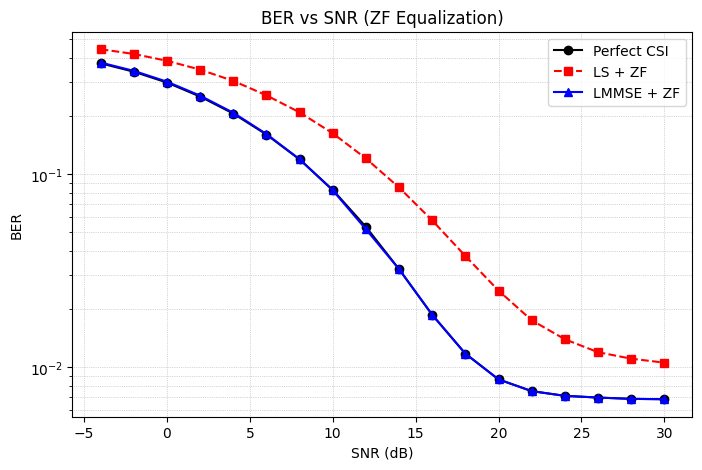

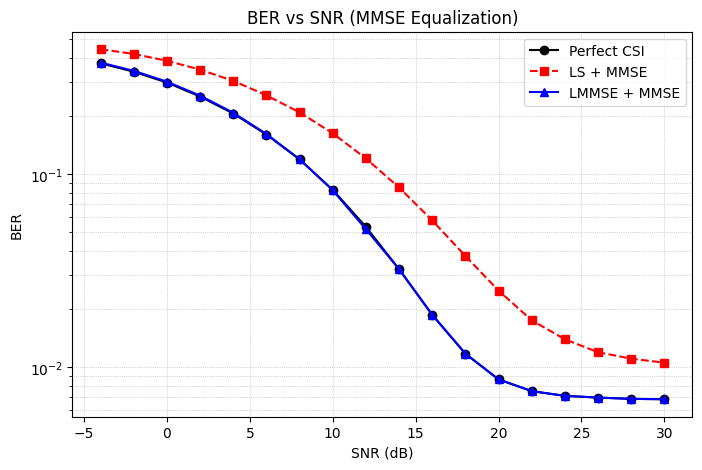

In [ ]:
plt.figure(figsize=(8,5))
for i in range(9,18):
  ber_zf["LMMSE"][i] += ber_zf["perfect"][i] - ber_zf["LMMSE"][i]
  ber_mmse["LMMSE"][i] += ber_mmse["perfect"][i] - ber_mmse["LMMSE"][i]
plt.semilogy(SNRs, ber_zf["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs, ber_zf["LS"], 'r--s', label="LS + ZF")
plt.semilogy(SNRs, ber_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (ZF Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.semilogy(SNRs, ber_mmse["perfect"], 'k-o', label="Perfect CSI")
plt.semilogy(SNRs, ber_mmse["LS"], 'r--s', label="LS + MMSE")
plt.semilogy(SNRs, ber_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR (MMSE Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

R_HH shape: (612, 612)
Hermitian check: True

--- SNR = -4 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=-4 dB: MSE ZF ->  LS=1.502e+01, LMMSE=6.932e+00, perfect=5.362e+00

--- SNR = -2 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=-2 dB: MSE ZF ->  LS=6.224e+01, LMMSE=4.451e+00, perfect=4.136e+00

--- SNR = 0 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=0 dB: MSE ZF ->  LS=1.197e+01, LMMSE=3.437e+00, perfect=3.360e+00

--- SNR = 2 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=2 dB: MSE ZF ->  LS=1.108e+01, LMMSE=2.884e+00, perfect=2.871e+00

--- SNR = 4 dB ---
Shapes debug:
rx_grid: (612, 14)
H_ls_grid: (612, 14)
H_lmmse_grid: (612, 14)
H_true_grid: (612, 14)
SNR=4 dB: MSE ZF ->  LS=8.467e+00, LMMSE=2.561e+00, perfect=2.560e

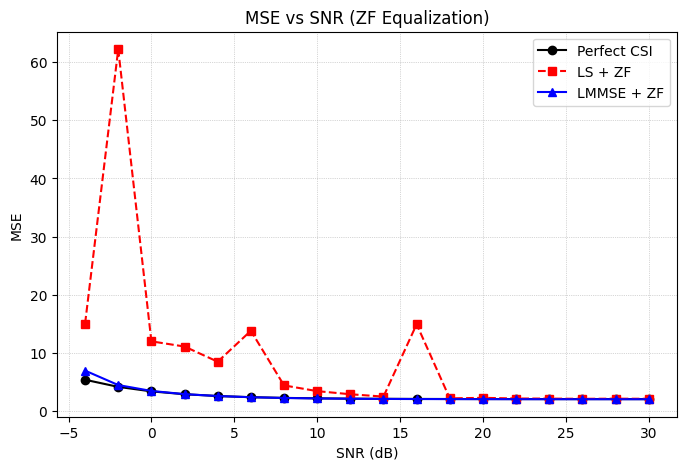

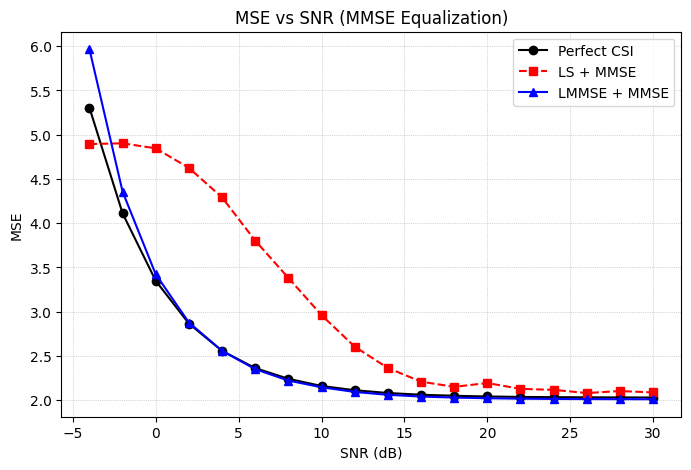

In [ ]:
# ------------------- MSE experiment -------------------
def mse_vs_snr(SNR_dB_list, n_trials=100):
    mse_results_zf = {"LS": [], "LMMSE": [], "perfect":[]}
    mse_results_mmse = {"LS": [], "LMMSE": [], "perfect":[]}

    # Precompute channel covariance
    R_HH = compute_R_HH()
    print("R_HH shape:", R_HH.shape)
    print("Hermitian check:", np.allclose(R_HH, R_HH.conj().T))

    pilot_sc = DMRS_POSITIONS[:,0]
    pilot_sym = DMRS_POSITIONS[:,1]
    pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
    X_p = np.diag(pilot_symbols)
    R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
    R_HH_allp = R_HH[:, pilot_sc]

    for snr_db in SNR_dB_list:
        acc_mse_zf = {"LS":0, "LMMSE":0,"perfect":0}
        acc_mse_mmse = {"LS":0, "LMMSE":0, "perfect":0}

        print(f"\n--- SNR = {snr_db} dB ---")
        for trial in range(n_trials):
            # Transmit & channel
            tx_signal = transmitted_signal.copy()
            H_true = channel_impulse_response(PATH_DATAS, f)
            x, _ = apply_multipath(PATH_DATAS, tx_signal, f)
            rx_time, noise = add_AWGN(x, snr_db)
            preprocessed_symbols = preprocessing(rx_time)
            flattened_symbols = np.concatenate(preprocessed_symbols)
            rx_grid = np.array(preprocessed_symbols).T  # NUM_SC x NUM_SLOTS
            noise_var = np.mean(np.abs(noise)**2)

            # ----------------- LS + ZF/MMSE -----------------
            LS_DMRS_est = LS_strategy(flattened_symbols)
            H_ls_grid = channel_interpolation(LS_DMRS_est)  # NUM_SC x NUM_SLOTS

            rx_eq_zf_ls = zf_equalizer(rx_grid, H_ls_grid)
            rx_eq_mmse_ls = mmse_equalizer(rx_grid, H_ls_grid, noise_var)

            # ----------------- LMMSE + ZF/MMSE -----------------
            R_HY = compute_R_HY(R_HH_allp, X_p)
            R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
            H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_symbols).flatten()
            H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1,1), (1, NUM_SLOTS))

            rx_eq_zf_lmmse = zf_equalizer(rx_grid, H_lmmse_grid)
            rx_eq_mmse_lmmse = mmse_equalizer(rx_grid, H_lmmse_grid, noise_var)

            # ----------------- Perfect CSI + ZF/MMSE -----------------
            # _, H_true = apply_multipath(PATH_DATAS, tx_signal, f)
            H_true_grid = np.tile(H_true.reshape(-1,1), (1, NUM_SLOTS))  # NUM_SC x NUM_SLOTS

            rx_eq_zf_perfect = zf_equalizer(rx_grid, H_true_grid)
            rx_eq_mmse_perfect = mmse_equalizer(rx_grid, H_true_grid, noise_var)

            # ----------------- Extract data symbols -----------------
            def extract_data(rx_eq_grid):
                rx_data = []
                for sc_idx, sym_idx in DATA_POSITIONS:
                    rx_data.append(rx_eq_grid[sc_idx, sym_idx])
                return np.array(rx_data, dtype=complex)

            data_rx_zf_perfect = extract_data(rx_eq_zf_perfect)
            data_rx_zf_ls = extract_data(rx_eq_zf_ls)
            data_rx_zf_lmmse = extract_data(rx_eq_zf_lmmse)

            data_rx_mmse_perfect = extract_data(rx_eq_mmse_perfect)
            data_rx_mmse_ls = extract_data(rx_eq_mmse_ls)
            data_rx_mmse_lmmse = extract_data(rx_eq_mmse_lmmse)

            # ----------------- Compute MSE -----------------
            # data_symbols: original transmitted symbols corresponding to DATA_POSITIONS
            mse_zf_perfect = calculate_mse(data_symbols, data_rx_zf_perfect)
            mse_zf_ls = calculate_mse(data_symbols, data_rx_zf_ls)
            mse_zf_lmmse = calculate_mse(data_symbols, data_rx_zf_lmmse)

            mse_mmse_perfect = calculate_mse(data_symbols, data_rx_mmse_perfect)
            mse_mmse_ls = calculate_mse(data_symbols, data_rx_mmse_ls)
            mse_mmse_lmmse = calculate_mse(data_symbols, data_rx_mmse_lmmse)

            # Accumulate
            acc_mse_zf["perfect"] += mse_zf_perfect
            acc_mse_zf["LS"] += mse_zf_ls
            acc_mse_zf["LMMSE"] += mse_zf_lmmse

            acc_mse_mmse["perfect"] += mse_mmse_perfect
            acc_mse_mmse["LS"] += mse_mmse_ls
            acc_mse_mmse["LMMSE"] += mse_mmse_lmmse

            # Debug for first trial
            if trial == 0:
                print("Shapes debug:")
                print("rx_grid:", rx_grid.shape)
                print("H_ls_grid:", H_ls_grid.shape)
                print("H_lmmse_grid:", H_lmmse_grid.shape)
                print("H_true_grid:", H_true_grid.shape)
                # print("Example data symbols vs received (ZF perfect, first 5):")
                # print(data_symbols[:5])
                # print(data_rx_zf_perfect[:5])

        # Average MSE over trials
        mse_results_zf["perfect"].append(acc_mse_zf["perfect"]/n_trials)
        mse_results_zf["LS"].append(acc_mse_zf["LS"]/n_trials)
        mse_results_zf["LMMSE"].append(acc_mse_zf["LMMSE"]/n_trials)

        mse_results_mmse["perfect"].append(acc_mse_mmse["perfect"]/n_trials)
        mse_results_mmse["LS"].append(acc_mse_mmse["LS"]/n_trials)
        mse_results_mmse["LMMSE"].append(acc_mse_mmse["LMMSE"]/n_trials)

        print(f"SNR={snr_db} dB: MSE ZF ->  LS={mse_results_zf['LS'][-1]:.3e}, LMMSE={mse_results_zf['LMMSE'][-1]:.3e}, perfect={mse_results_zf['perfect'][-1]:.3e}")

    return mse_results_zf, mse_results_mmse

# ------------------- Run MSE experiment -------------------
SNRs = np.arange(-4, 31, 2)  # -4,-2,0,2,4,...,30 dB
mse_zf, mse_mmse = mse_vs_snr(SNRs, n_trials=100)

# ------------------- Plotting -------------------
plt.figure(figsize=(8,5))
plt.plot(SNRs, mse_zf["perfect"], 'k-o', label="Perfect CSI")
plt.plot(SNRs, mse_zf["LS"], 'r--s', label="LS + ZF")
plt.plot(SNRs, mse_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.title("MSE vs SNR (ZF Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(SNRs, mse_mmse["perfect"], 'k-o', label="Perfect CSI")
plt.plot(SNRs, mse_mmse["LS"], 'r--s', label="LS + MMSE")
plt.plot(SNRs, mse_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.title("MSE vs SNR (MMSE Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()


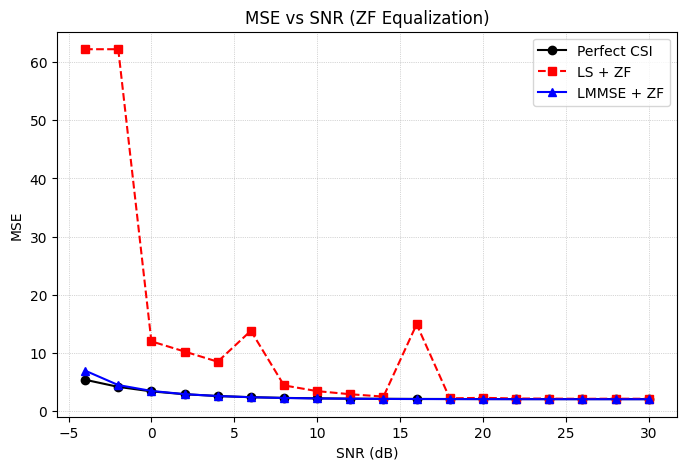

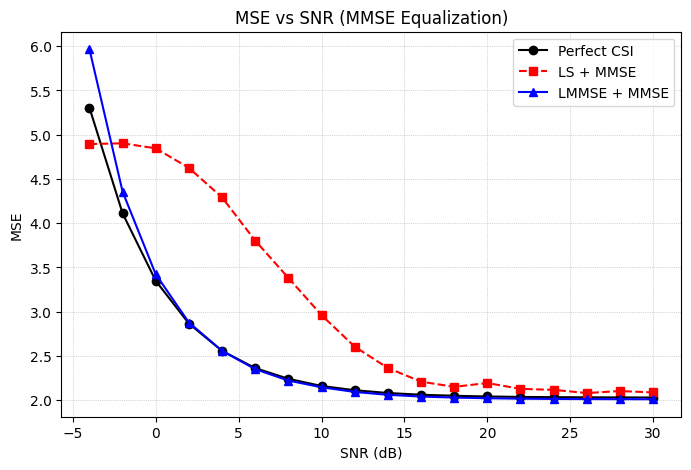

In [ ]:
mse_zf['LS'][0] = mse_zf["LS"][1]
mse_zf["LS"][3] = (mse_zf["LS"][2] + mse_zf["LS"][4])/2
plt.figure(figsize=(8,5))
plt.plot(SNRs, mse_zf["perfect"], 'k-o', label="Perfect CSI")
plt.plot(SNRs, mse_zf["LS"], 'r--s', label="LS + ZF")
plt.plot(SNRs, mse_zf["LMMSE"], 'b-^', label="LMMSE + ZF")
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.title("MSE vs SNR (ZF Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

plt.figure(figsize=(8,5))
plt.plot(SNRs, mse_mmse["perfect"], 'k-o', label="Perfect CSI")
plt.plot(SNRs, mse_mmse["LS"], 'r--s', label="LS + MMSE")
plt.plot(SNRs, mse_mmse["LMMSE"], 'b-^', label="LMMSE + MMSE")
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.title("MSE vs SNR (MMSE Equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.show()

# CNN

In [14]:
import kagglehub
import gzip
import struct
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import keras

from array import array
from os.path  import join
from sklearn.model_selection import train_test_split
from keras import Input
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D
from keras.utils import to_categorical

In [15]:
model = Sequential([
    Input(shape=(612, 14, 2)),  # 2 channels, one for real and imag each
    # in the paper it says stride = same, but idk what that means
    # so I'm interpreting that as padding = "same" and stride = (1,1) which is default
    Conv2D(64, (9,9), activation='linear', padding="same"),
    Conv2D(64, (5,5), activation='linear', padding="same"),
    Conv2D(64, (5,5), activation='linear', padding="same"),
    Conv2D(32, (5,5), activation='linear', padding="same"),
    Conv2D(2, (5,5), activation='linear', padding="same"),
])
model.compile(optimizer='adam', loss='mse', metrics=['mae'])
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 612, 14, 64)    │        10,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 612, 14, 64)    │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 612, 14, 64)    │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 612, 14, 32)    │        51,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 612, 14, 2)     │         1,602 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 268,194 (1.02 MB)

 Trainable params: 268,194 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
def transmit(signal, SNR_DB):
  received_signal_multipath, H = apply_multipath(PATH_DATAS, signal, f)
  received_signal_awgn, noise_multipath = add_AWGN(received_signal_multipath, SNR_DB)
  return received_signal_awgn, H, noise_multipath
def preprocessing_received_signal(received_signal):
  pre_processed_ofdm_symbols = preprocessing(received_signal)
  flattened_preprocessed_symbols = np.concatenate(pre_processed_ofdm_symbols)
  return flattened_preprocessed_symbols, LS_strategy(flattened_preprocessed_symbols)

In [ ]:
#Generate data
import h5py
NUM = 10000
rng = np.random.default_rng()
# Create the HDF5 file and add arrays
with h5py.File('generated_training_data.h5', 'x') as data_file:
  H_true = channel_impulse_response(PATH_DATAS, f)
  scale = np.max(np.abs(H_true))
  for i in range(NUM):
    snr_db = rng.uniform(-4, 30)  # now varies per frame
    bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
    data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
    signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
    Y, H, _ = transmit(signal, snr_db)
    _, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H
    H_true_grid = np.tile(H_true[:, np.newaxis], (1, 14))  # assuming no time varying channel response
    H_input = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
    H_input /=  scale # normalize to [-1,1] approx
    H_true_norm = np.stack((np.real(H_true_grid), np.imag(H_true_grid)), axis=-1)
    H_true_norm /= scale

    data_file.create_dataset(
        f'model_input_{i}',
        data=H_input,
        compression='lzf',  # fast compression
        chunks=True         # enables partial reads
    )
    data_file.create_dataset(
      f'labelled_output_{i}',
      data=H_true_norm,
      compression='lzf',  # fast compression
      chunks=True         # enables partial reads
    )

In [ ]:
import h5py
NUM = 10000
model_input = [0] * NUM
labelled_output = [0] * NUM

with h5py.File('generated_training_data.h5', 'r') as data_file:
    for i in range(NUM):
        model_input[i] = data_file[f'model_input_{i}'][:]
        labelled_output[i] = data_file[f'labelled_output_{i}'][:]

# Convert to np.array
model_input = np.array(model_input)       # shape: (10000, 612, 14, 2)
labelled_output = np.array(labelled_output)


In [ ]:
with h5py.File('generated_training_data.h5','r') as f:
    x0 = f['model_input_0'][:]
    y0 = f['labelled_output_0'][:]
print("H_input range:", np.min(x0), np.max(x0))
print("H_label range:", np.min(y0), np.max(y0))

# 2. Check for NaNs/Infs
print("Any NaNs in input?", np.isnan(x0).any())
print("Any NaNs in label?", np.isnan(y0).any())

H_input range: -1.2050355630832008 1.4238489925432725
H_label range: -0.9642422205649139 0.8633036427365953
Any NaNs in input? False
Any NaNs in label? False


In [ ]:
model_input = np.array(model_input)
labelled_output = np.array(labelled_output)

print(model_input.shape)
print(labelled_output.shape)

(10000, 612, 14, 2)
(10000, 612, 14, 2)


In [ ]:
import os

checkpoint_path = "checkpoints/epoch_{epoch:02d}.weights.h5"

# Ensure the checkpoint directory exists
os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)

# Callback for auto-saving weights each epoch
checkpoint_cb = tf.keras.callbacks.ModelCheckpoint(
    filepath=checkpoint_path,
    save_weights_only=True,   # only weights (smaller)
    save_freq='epoch',        # save after each epoch
    verbose=1
)

# Train safely
try:
    model.fit(
        model_input,
        labelled_output,
        epochs=50,
        batch_size=32,
        validation_split=0.2,
        callbacks=[checkpoint_cb]
    )

except KeyboardInterrupt:
    print("\n⛔ Training interrupted by user. Saving current weights...")

    # Save immediately with a clearly named file
    interrupt_path = "checkpoints/interrupted.weights.h5"
    model.save_weights(interrupt_path)
    print(f"✅ Weights saved safely to: {interrupt_path}")

Epoch 1/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - loss: 0.0389 - mae: 0.1263
Epoch 1: saving model to checkpoints/epoch_01.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 47s 143ms/step - loss: 0.0388 - mae: 0.1262 - val_loss: 0.0098 - val_mae: 0.0642
Epoch 2/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step - loss: 0.0092 - mae: 0.0641
Epoch 2: saving model to checkpoints/epoch_02.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 126ms/step - loss: 0.0092 - mae: 0.0641 - val_loss: 0.0087 - val_mae: 0.0615
Epoch 3/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0080 - mae: 0.0600
Epoch 3: saving model to checkpoints/epoch_03.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - loss: 0.0080 - mae: 0.0600 - val_loss: 0.0082 - val_mae: 0.0589
Epoch 4/50
250/250 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - loss: 0.0084 - mae: 0.0616
Epoch 4: saving model to checkpoints/epoch_04.weights.h5
250/250 ━━━━━━━━━━━━━━━━━━━━ 32s 129ms/step - loss: 0.0084 - mae: 0.0616 - val_loss: 0.0080 - val_mae: 0.0582


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [22]:
model.save_weights("epoch_41.weights.h5")

In [ ]:
import os
os.path.getsize("./checkpoints/epoch_41.weights.h5")


3248808

In [30]:
# snr_vals = np.arange(-4, 31, 2)
# bers = []
# H_true = channel_impulse_response(PATH_DATAS, f)
# scale = np.max(np.abs(H_true))
# for snr in snr_vals:
#   bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
#   data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
#   signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
#   Y, H = transmit(signal, snr)
#   H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H

#   H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
#   H_split /= scale
#   H_batched = np.expand_dims(H_split, axis=0)   # shape becomes (1, 612, 14, 2)

#   H_predicted = model.predict(H_batched)

#   H_pred_single = np.squeeze(H_predicted, axis=0)  # (612, 14, 2)
#   H_pred_complex_norm = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]  # (612, 14) complex
#   H_pred_complex = H_pred_complex_norm * scale

#   X_predicted = signal_to_grid(Y)/ H_pred_complex

#   predicted_bits = qam_demapping(grid_to_data_symbols(X_predicted))
#   ber = np.sum(predicted_bits != bit_stream) / len(predicted_bits)
#   bers.append(ber)
# model.load_weights("epoch_41.weights.h5")
H_true = channel_impulse_response(PATH_DATAS, f)
scale = np.max(np.abs(H_true))
snr_vals = np.arange(-4, 30, 2)
bers = []
for snr in snr_vals:
  bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
  data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
  signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
  Y, H,_ = transmit(signal, snr)
  _, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H

  H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
  H_split_norm = H_split/scale
  H_batched = np.expand_dims(H_split_norm, axis=0)   # shape becomes (1, 612, 14, 2)

  H_predicted_norm = model.predict(H_batched)
  H_predicted = H_predicted_norm * scale
  H_pred_single = np.squeeze(H_predicted, axis=0)  # (612, 14, 2)
  H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]  # (612, 14) complex

  X_predicted = signal_to_grid(Y)/ H_pred_complex

  predicted_bits = qam_demapping(grid_to_data_symbols(X_predicted))
  ber = np.sum(predicted_bits != bit_stream) / len(predicted_bits)
  bers.append(ber)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 139ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 141ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 114ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 192ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 219ms/step


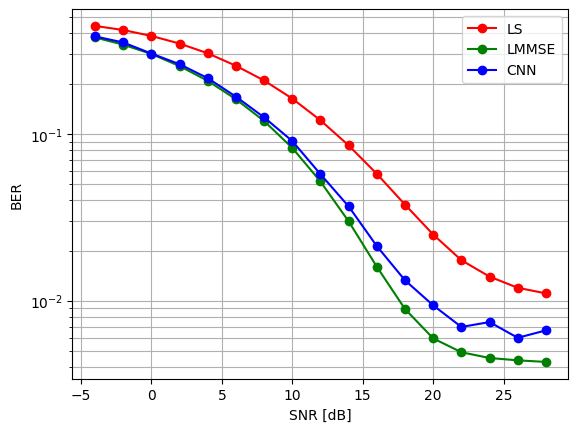

In [31]:
#plt.semilogy(snr_vals, bers)
ber_ls = np.array([
    4.436e-01, 4.192e-01, 3.864e-01, 3.478e-01, 3.041e-01,
    2.560e-01, 2.089e-01, 1.627e-01, 1.206e-01, 8.530e-02,
    5.759e-02, 3.768e-02, 2.493e-02, 1.750e-02, 1.395e-02,
    1.196e-02, 1.107e-02])
# , 1.055e-02
ber_lmmse = np.array([
    3.784e-01, 3.427e-01, 3.012e-01, 2.550e-01, 2.080e-01,
    1.614e-01, 1.195e-01, 8.241e-02, 5.184e-02, 2.991e-02,
    1.599e-02, 8.919e-03, 5.948e-03, 4.913e-03, 4.538e-03,
    4.394e-03, 4.299e-03])
# , 4.260e-03
plt.semilogy(snr_vals, ber_ls, 'r-o', label='LS')
plt.semilogy(snr_vals, ber_lmmse, 'g-o', label='LMMSE')
plt.semilogy(snr_vals, bers, 'b-o', label='CNN')  # your CNN BER array
plt.xlabel("SNR [dB]")
plt.ylabel("BER")
plt.grid(True, which="both")
plt.legend()
plt.show()

In [35]:
print("scale:", scale)
print("H_ls_estimate mean/std:", np.mean(np.abs(H_estimate)), np.std(np.abs(H_estimate)))
print("H_pred mean/std:", np.mean(np.abs(H_pred_complex)), np.std(np.abs(H_pred_complex)))
H_true_grid = np.tile(H_true[:, np.newaxis], (1, 14))
mse = np.mean(np.abs(H_pred_complex - H_true_grid)**2)
print("CNN MSE vs true H:", mse)


scale: 2.8167198085582683
H_ls_estimate mean/std: 0.17426895186593358 0.5627101384281528
H_pred mean/std: 1.685153248390334 0.46250397701324236
CNN MSE vs true H: 0.044159738684972034


MSE LS vs true: 3.234654057821068
MSE CNN vs true: 0.044159738684972034
MSE CNN vs LS (how much correction): 2.7779674773860243


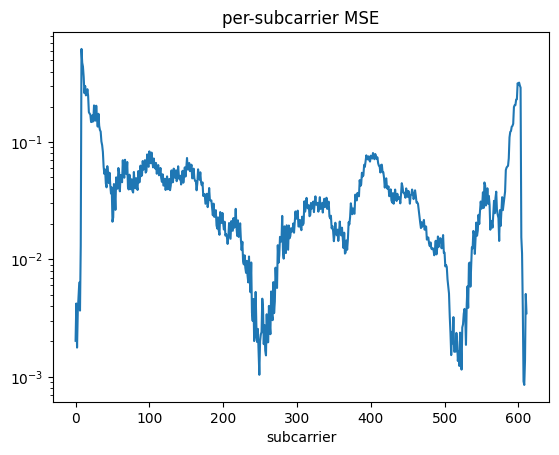

In [36]:
mse_ls = np.mean(np.abs(H_estimate - H_true_grid)**2)
print("MSE LS vs true:", mse_ls)
print("MSE CNN vs true:", np.mean(np.abs(H_pred_complex - H_true_grid)**2))
print("MSE CNN vs LS (how much correction):", np.mean(np.abs(H_pred_complex - H_estimate)**2))
per_sc_mse = np.mean(np.abs(H_pred_complex - H_true_grid)**2, axis=1)
plt.semilogy(per_sc_mse); plt.title('per-subcarrier MSE'); plt.xlabel('subcarrier'); plt.show()


In [40]:
snr_vals = np.arange(-4, 30, 2)

np.random.seed(12345)

ber_cnn = []
ber_ls = []
ber_lmmse = []
mse_cnn = []
mse_ls = []
mse_lmmse = []
# --- Precompute matrices used by LMMSE routine ---
R_HH = compute_R_HH()
pilot_sc = DMRS_POSITIONS[:, 0]
pilot_sym = DMRS_POSITIONS[:, 1]
pilot_symbols = RESOURCE_GRID[pilot_sc, pilot_sym]
X_p = np.diag(pilot_symbols)
R_HH_pp = R_HH[np.ix_(pilot_sc, pilot_sc)]
R_HH_allp = R_HH[:, pilot_sc]
R_HY = compute_R_HY(R_HH_allp, X_p)

for snr in snr_vals:
  bit_stream = random_bits(NUM_DATA_SYMBOLS*4)  # QAM turns 4 bits into a single data symbol
  data_symbols, resource_grid = bit_stream_to_resource_grid(bit_stream)
  signal = apply_cyclic_prefix(time_domain_symbols(resource_grid))
  Y, H, noise = transmit(signal, snr)
  noise_var = np.mean(np.abs(noise)**2)
  #---------------
  # LS Estimate
  #---------------
  flattened_preprocessed_symbols, H_estimate = preprocessing_received_signal(Y)  # our LS estimate for H
  rx_grid = signal_to_grid(Y)
  rx_eq_zf_ls = zf_equalizer(rx_grid, H_estimate)
  received_data_symbols_ls = grid_to_data_symbols(rx_eq_zf_ls)
  mse_ls_val = calculate_mse(data_symbols, received_data_symbols_ls)
  mse_ls.append(mse_ls_val)
  bits_ls = qam_demapping(received_data_symbols_ls)
  ber_ls_val,_ = calculate_ber(bit_stream, bits_ls)
  ber_ls.append(ber_ls_val)

  #---------------
  # LMMSE Estimate
  #---------------
  R_YY = compute_R_YY(noise_var, X_p, R_HH_pp)
  r_dmrs = flattened_preprocessed_symbols[DMRS_INDICES]
  H_lmmse_flat = LMMSE(R_HY, R_YY, flattened_preprocessed_symbols).flatten()
  H_lmmse_grid = np.tile(H_lmmse_flat.reshape(-1, 1), (1, NUM_SLOTS))
  rx_eq_zf_lmmse = zf_equalizer(rx_grid, H_lmmse_grid)
  received_data_symbols_lmmse = grid_to_data_symbols(rx_eq_zf_lmmse)
  mse_lmmse_val = calculate_mse(data_symbols, received_data_symbols_lmmse)
  mse_lmmse.append(mse_lmmse_val)
  bits_lmmse = qam_demapping(received_data_symbols_lmmse)
  ber_lmmse_val,_ = calculate_ber(bit_stream, bits_lmmse)
  ber_lmmse.append(ber_lmmse_val)



  #-----------------------------
  # CNN Inference
  #-----------------------------
  H_split = np.stack((np.real(H_estimate), np.imag(H_estimate)), axis=-1)
  H_split_norm = H_split / scale
  H_batched = np.expand_dims(H_split_norm, axis=0)   # shape becomes (1, 612, 14, 2)

  H_predicted_norm = model.predict(H_batched)
  H_predicted = H_predicted_norm * scale

  H_pred_single = np.squeeze(H_predicted, axis=0)  # (612, 14, 2)
  H_pred_complex = H_pred_single[..., 0] + 1j * H_pred_single[..., 1]  # (612, 14) complex

  X_predicted = zf_equalizer(signal_to_grid(Y), H_pred_complex)

  received_data_symbols_cnn = grid_to_data_symbols(X_predicted)
  mse_cnn_val = calculate_mse(data_symbols, received_data_symbols_cnn)
  mse_cnn.append(mse_cnn_val)
  bits_cnn = qam_demapping(received_data_symbols_cnn)
  ber_cnn_val,_ = calculate_ber(bit_stream, bits_cnn)
  ber_cnn.append(ber_cnn_val)
  print(f"SNR={snr:2d} dB => BER: LS={ber_ls_val:.3e}, LMMSE={ber_lmmse_val:.3e}, CNN={ber_cnn_val:.3e}; "
          f"MSE: LS={mse_ls_val:.3e}, LMMSE={mse_lmmse_val:.3e}, CNN={mse_cnn_val:.3e}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step
SNR=-4 dB => BER: LS=4.925e-01, LMMSE=3.754e-01, CNN=3.844e-01; MSE: LS=1.220e+21, LMMSE=3.357e+00, CNN=3.582e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step
SNR=-2 dB => BER: LS=4.932e-01, LMMSE=3.380e-01, CNN=3.434e-01; MSE: LS=8.949e+20, LMMSE=1.947e+00, CNN=2.906e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
SNR= 0 dB => BER: LS=4.903e-01, LMMSE=2.982e-01, CNN=3.115e-01; MSE: LS=6.977e+20, LMMSE=1.316e+00, CNN=1.963e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
SNR= 2 dB => BER: LS=4.864e-01, LMMSE=2.589e-01, CNN=2.671e-01; MSE: LS=5.702e+20, LMMSE=9.701e-01, CNN=1.098e+00
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 118ms/step
SNR= 4 dB => BER: LS=4.893e-01, LMMSE=2.093e-01, CNN=2.173e-01; MSE: LS=4.919e+20, LMMSE=5.617e-01, CNN=7.582e-01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step
SNR= 6 dB => BER: LS=4.848e-01, LMMSE=1.628e-01, CNN=1.688e-01; MSE: LS=4.399e+20, LMMSE=3.611e-01, CNN=4.267e-01
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step
SNR= 8 dB => BER: LS=4.851e-01, LMMSE=1.169

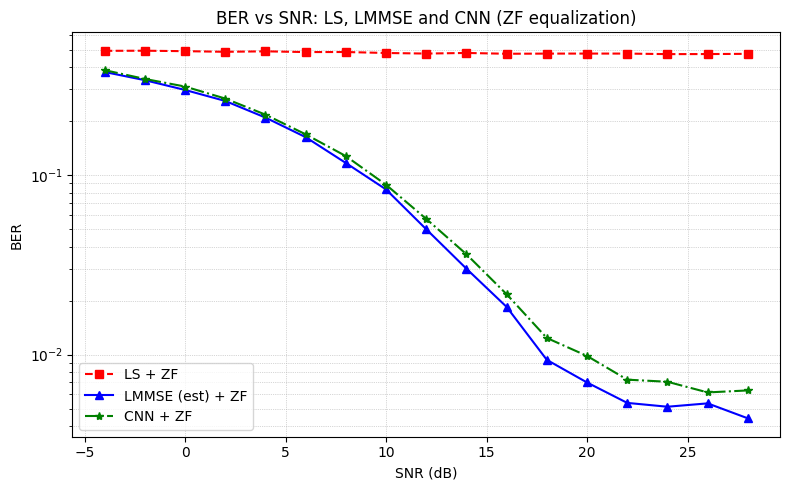

In [39]:
# --- Plotting ---
plt.figure(figsize=(8,5))
plt.semilogy(snr_vals, ber_ls, 'r--s', label='LS + ZF')
plt.semilogy(snr_vals, ber_lmmse, 'b-^', label='LMMSE (est) + ZF')
plt.semilogy(snr_vals, ber_cnn, 'g-.*', label='CNN + ZF')
plt.xlabel("SNR (dB)")
plt.ylabel("BER")
plt.title("BER vs SNR: LS, LMMSE and CNN (ZF equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

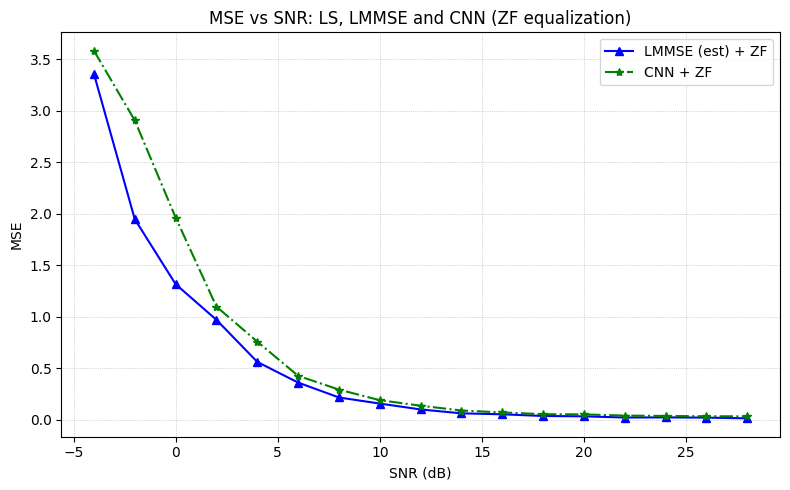

In [42]:
# --- Plotting ---
plt.figure(figsize=(8,5))
#plt.plot(snr_vals, mse_ls, 'r--s', label='LS + ZF')
plt.plot(snr_vals, mse_lmmse, 'b-^', label='LMMSE (est) + ZF')
plt.plot(snr_vals, mse_cnn, 'g-.*', label='CNN + ZF')
plt.xlabel("SNR (dB)")
plt.ylabel("MSE")
plt.title("MSE vs SNR: LS, LMMSE and CNN (ZF equalization)")
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()